In [ ]:
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')
feature_df = pd.read_pickle("/content/drive/MyDrive/SmartRail/features_engineered.pkl")
feature_df.shape

Mounted at /content/drive


(1459444, 43)

In [ ]:
from sklearn.preprocessing import StandardScaler

X = feature_df.drop(columns=["failure"])
y = feature_df["failure"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled.shape

(1459444, 42)

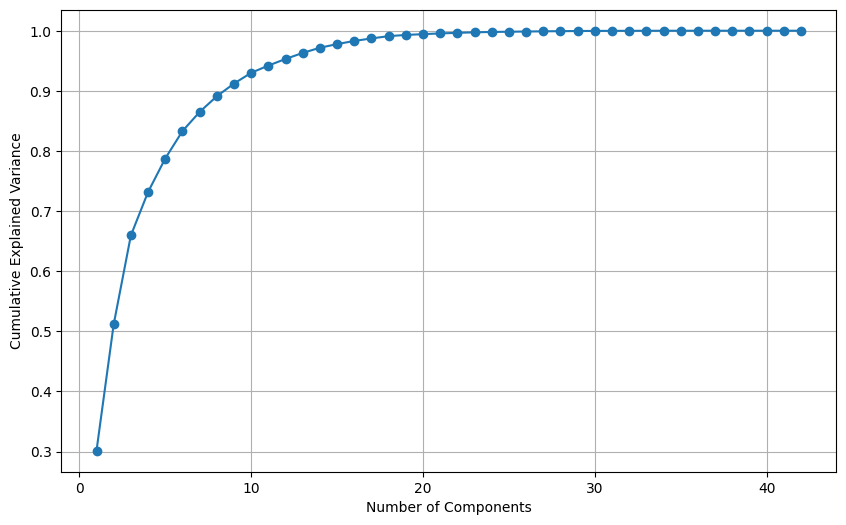

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca_full = PCA()
pca_full.fit(X_scaled)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca_full.explained_variance_ratio_)+1),
         pca_full.explained_variance_ratio_.cumsum(), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()

In [ ]:
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

print(pca.explained_variance_ratio_.sum())
X_pca.shape

0.9299850699878239


(1459444, 10)

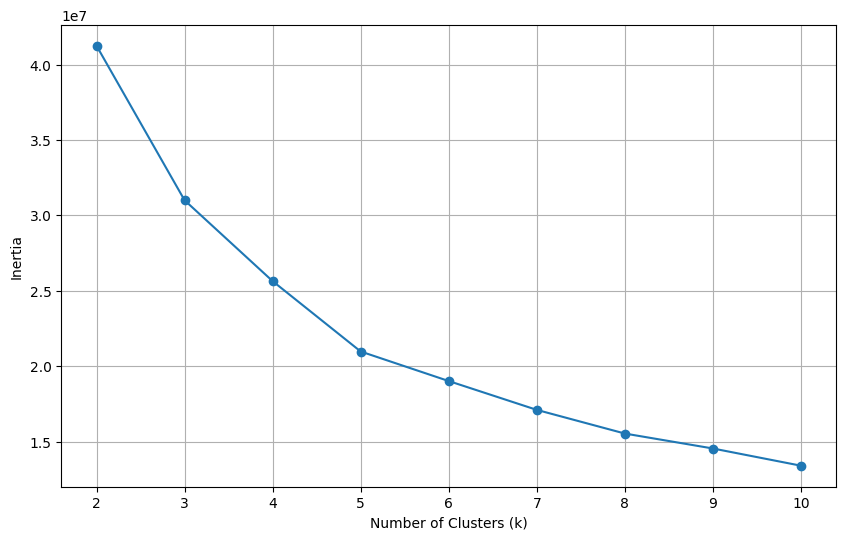

In [ ]:
from sklearn.cluster import KMeans

inertias = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca)
    inertias.append(km.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score
import numpy as np

sample_idx = np.random.choice(X_pca.shape[0], 20000, replace=False)
X_sample = X_pca[sample_idx]

sil_scores = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_sample)
    score = silhouette_score(X_sample, labels)
    sil_scores.append(score)
    print(f"k={k}, silhouette={score:.4f}")

k=2, silhouette=0.4127
k=3, silhouette=0.4471
k=4, silhouette=0.4812
k=5, silhouette=0.3897
k=6, silhouette=0.3838
k=7, silhouette=0.3848


In [ ]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_pca)

feature_df["kmeans_cluster"] = cluster_labels
feature_df["kmeans_cluster"].value_counts()

,count
kmeans_cluster,
1,944519
0,303346
2,146208
3,65371


In [ ]:
cluster_summary = feature_df.groupby("kmeans_cluster")[
    ["TP2_roll_mean", "TP3_roll_mean", "Motor_current_roll_mean",
     "Oil_temperature_roll_mean", "failure"]
].mean()

cluster_summary

,TP2_roll_mean,TP3_roll_mean,Motor_current_roll_mean,Oil_temperature_roll_mean,failure
kmeans_cluster,,,,,
0,3.342673,9.429931,4.101861,65.417003,0.000162
1,-0.009381,8.991611,1.141460,61.278770,0.000015
2,2.543301,8.409045,1.945123,60.254216,0.000424
3,8.290682,8.444463,5.590882,74.829239,0.454911


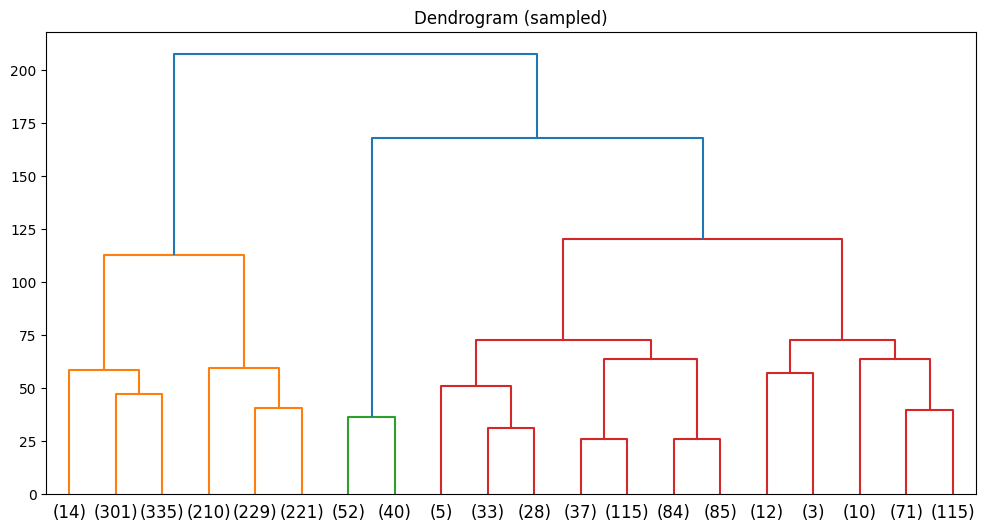

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

sample_idx2 = np.random.choice(X_pca.shape[0], 2000, replace=False)
X_sample2 = X_pca[sample_idx2]

linked = linkage(X_sample2, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='lastp', p=20)
plt.title("Dendrogram (sampled)")
plt.show()


In [ ]:
import joblib

feature_df.to_pickle("/content/drive/MyDrive/SmartRail/features_with_clusters.pkl")
joblib.dump(scaler, "/content/drive/MyDrive/SmartRail/scaler.pkl")
joblib.dump(pca, "/content/drive/MyDrive/SmartRail/pca.pkl")
joblib.dump(kmeans_final, "/content/drive/MyDrive/SmartRail/kmeans.pkl")

import numpy as np
np.save("/content/drive/MyDrive/SmartRail/X_pca.npy", X_pca)